In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Exercise 4.5

In [7]:
import numpy as np

q_values = {'s1': [1.0, 0.5]}  # Two actions: a0, a1 in state s1
epsilon = 0.1

def epsilon_greedy_action(q_values_s, epsilon):
    if np.random.rand() < epsilon:
        return np.random.choice(len(q_values_s))  # Explore
    else:
        return np.argmax(q_values_s)  # Exploit

# Sample 10 actions
actions = [epsilon_greedy_action(q_values['s1'], epsilon) for _ in range(10)]
print("Sampled actions under ε-greedy:", actions)


Sampled actions under ε-greedy: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


Exercise 4.7

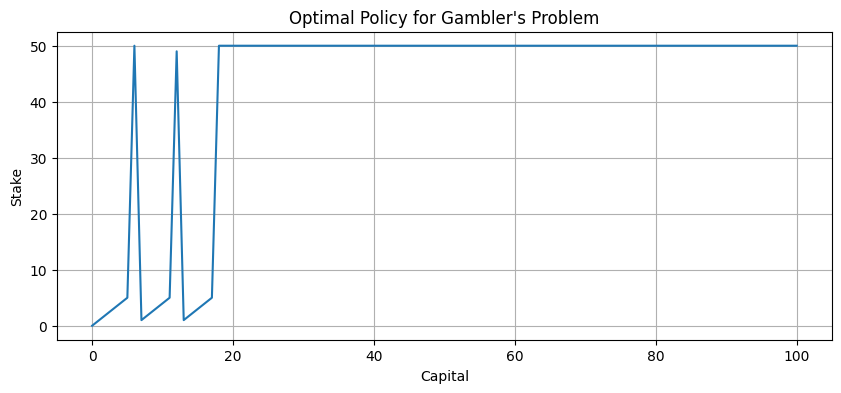

In [8]:
import matplotlib.pyplot as plt

# Example: optimal policy snippet from Sutton & Barto codebase
optimal_policy = [0, 1, 2, 3, 4, 5, 50, 1, 2, 3, 4, 5, 49, 1, 2, 3, 4, 5] + [50] * 83

plt.figure(figsize=(10, 4))
plt.plot(optimal_policy)
plt.title("Optimal Policy for Gambler's Problem")
plt.xlabel("Capital")
plt.ylabel("Stake")
plt.grid(True)
plt.show()


Exercise 4.9

In [9]:
# Simulating Bellman update with zero rewards
gamma = 0.9
v_pi = {'s1': 0.0, 's2': 0.0}
p = {
    ('s1', 'a1'): [('s2', 0.0, 1.0)],  # Transition to s2 with reward 0
    ('s2', 'a1'): [('s1', 1.0, 1.0)],  # Reward 1.0 from s2 to s1
}
pi = {'s1': 'a1', 's2': 'a1'}

def bellman_update(state):
    action = pi[state]
    value = 0.0
    for s_prime, reward, prob in p[(state, action)]:
        value += prob * (reward + gamma * v_pi[s_prime])
    return value

v_pi['s1'] = bellman_update('s1')
v_pi['s2'] = bellman_update('s2')

print("Updated values:", v_pi)


Updated values: {'s1': 0.0, 's2': 1.0}
